In [9]:
import pandas as pd
data = pd.read_csv("cooking_fuel.csv")

In [10]:
# ===== STEP 1: PREP =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data['sale_date'] = pd.to_datetime(data['sale_date'])
data = data.sort_values(['customer_id', 'sale_date']).reset_index(drop=True)

# Calculate raw gaps
data['day_gap'] = data.groupby('customer_id')['sale_date'].diff().dt.days

print(data[['customer_id', 'first_name', 'sale_date', 'day_gap']].head(20))

    customer_id first_name  sale_date  day_gap
0       1044891     Vikram 2024-02-22      NaN
1       1044891     Vikram 2024-04-14     52.0
2       1044891     Vikram 2024-06-10     57.0
3       1044891     Vikram 2024-07-31     51.0
4       1044891     Vikram 2024-09-13     44.0
5       1044891     Vikram 2024-10-30     47.0
6       1047572    Patrick 2024-05-10      NaN
7       1047572    Patrick 2024-08-01     83.0
8       1098919    Hiroshi 2024-01-31      NaN
9       1098919    Hiroshi 2024-03-26     55.0
10      1098919    Hiroshi 2024-07-20    116.0
11      1098919    Hiroshi 2024-09-11     53.0
12      1098919    Hiroshi 2024-10-25     44.0
13      1098919    Hiroshi 2024-12-21     57.0
14      1157662     Olivia 2024-01-08      NaN
15      1279121    Takeshi 2024-02-20      NaN
16      1432519        Ana 2024-01-24      NaN
17      1432519        Ana 2024-02-14     21.0
18      1432519        Ana 2024-03-20     35.0
19      1432519        Ana 2024-05-12     53.0


In [11]:
# ===== STEP 2: HOW MANY PURCHASES PER CUSTOMER? =====
# Before anything — know who has enough data to analyze
purchase_counts = data.groupby('customer_id').size().reset_index(name='total_purchases')

print(purchase_counts['total_purchases'].value_counts().sort_index())
print(f"\nCustomers with only 1 purchase (no gaps possible): "
      f"{(purchase_counts['total_purchases'] == 1).sum()}")
print(f"Customers with 2+ purchases (gaps exist): "
      f"{(purchase_counts['total_purchases'] >= 2).sum()}")

total_purchases
1     26
2     29
3     41
4     36
5     41
6     40
7     26
8      2
9      5
10    12
11    12
12    15
13     7
14     5
Name: count, dtype: int64

Customers with only 1 purchase (no gaps possible): 26
Customers with 2+ purchases (gaps exist): 271


In [12]:
# ===== STEP 3: FOR EACH CUSTOMER — SEE ALL THEIR GAPS =====
# Focus only on customers with repeat purchases
repeat_customers = purchase_counts[purchase_counts['total_purchases'] >= 2]['customer_id']
gap_data = data[data['customer_id'].isin(repeat_customers) & data['day_gap'].notna()].copy()

# Per-customer gap profile
gap_profile = gap_data.groupby('customer_id')['day_gap'].agg(
    num_gaps       = 'count',
    avg_gap        = 'mean',
    median_gap     = 'median',
    min_gap        = 'min',
    max_gap        = 'max',
    std_gap        = 'std',        # high std = irregular buyer
    total_gap_span = 'sum'         # total days covered across all gaps
).round(1).reset_index()

# Coefficient of variation — how consistent is their cycle?
# Low CV (< 0.3) = very regular,  High CV (> 0.7) = erratic
gap_profile['CV'] = (gap_profile['std_gap'] / gap_profile['avg_gap']).round(2)

print("=== Gap Profile Per Customer ===")
print(gap_profile.sort_values('avg_gap'))

=== Gap Profile Per Customer ===
     customer_id  num_gaps  avg_gap  median_gap  min_gap  max_gap  std_gap  \
95       4052834         9     23.4        23.0     17.0     30.0      4.5   
251      9517169        13     23.9        22.0     16.0     37.0      6.3   
177      7224540        12     24.1        24.5     15.0     33.0      5.8   
96       4240708        13     24.5        24.0     15.0     33.0      5.1   
260      9796605         9     24.9        28.0     14.0     36.0      7.0   
..           ...       ...      ...         ...      ...      ...      ...   
229      8876742         1    181.0       181.0    181.0    181.0      NaN   
91       3937508         1    186.0       186.0    186.0    186.0      NaN   
240      9209880         1    187.0       187.0    187.0    187.0      NaN   
119      5334434         1    191.0       191.0    191.0    191.0      NaN   
126      5476583         1    197.0       197.0    197.0    197.0      NaN   

     total_gap_span    CV  
95

In [13]:
# ===== STEP 4: CLASSIFY CUSTOMER BUYING BEHAVIOR =====
def classify_behavior(row):
    if row['num_gaps'] < 2:
        return 'too few gaps'
    cv  = row['CV']
    avg = row['avg_gap']
    if cv < 0.3:
        return 'regular'          # buys on a steady clock
    elif cv < 0.6:
        return 'semi-regular'     # mostly consistent with some variation
    else:
        return 'irregular'        # unpredictable timing

gap_profile['behavior'] = gap_profile.apply(classify_behavior, axis=1)

print("\n=== Behavior Classification ===")
print(gap_profile['behavior'].value_counts())
print()
print(gap_profile[['customer_id','avg_gap','median_gap','std_gap','CV','behavior']]
      .sort_values('CV'))


=== Behavior Classification ===
behavior
regular         160
semi-regular     76
too few gaps     29
irregular         6
Name: count, dtype: int64

     customer_id  avg_gap  median_gap  std_gap    CV      behavior
47       2567468     88.5        88.5      0.7  0.01       regular
83       3698193     80.5        80.5      0.7  0.01       regular
122      5428914     92.5        92.5      0.7  0.01       regular
156      6507321     92.5        92.5      0.7  0.01       regular
133      5801541     80.5        80.5      2.1  0.03       regular
..           ...      ...         ...      ...   ...           ...
240      9209880    187.0       187.0      NaN   NaN  too few gaps
258      9748499     92.0        92.0      NaN   NaN  too few gaps
265      9911492    127.0       127.0      NaN   NaN  too few gaps
267      9961299    106.0       106.0      NaN   NaN  too few gaps
268      9988193    174.0       174.0      NaN   NaN  too few gaps

[271 rows x 6 columns]


In [14]:
# ===== STEP 5: SPOT THE BURST PATTERN (0,10,20 ... 100,110,120) =====
# For each customer — are their gaps SMALL sometimes and LARGE other times?
# That means two-speed buyer

def detect_two_speed(group):
    gaps = group['day_gap'].dropna()
    if len(gaps) < 3:
        return 'insufficient data'
    q1 = gaps.quantile(0.25)
    q3 = gaps.quantile(0.75)
    iqr = q3 - q1
    spread_ratio = gaps.max() / (gaps.median() + 1)  # avoid div by zero
    if spread_ratio > 4 and iqr > 20:
        return 'burst + hibernation'   # clear two-speed pattern
    return 'steady'

speed_type = (gap_data.groupby('customer_id')
              .apply(detect_two_speed)
              .reset_index(name='purchase_pattern'))

gap_profile = gap_profile.merge(speed_type, on='customer_id')

print("\n=== Purchase Pattern ===")
print(gap_profile['purchase_pattern'].value_counts())


=== Purchase Pattern ===
purchase_pattern
steady               201
insufficient data     70
Name: count, dtype: int64


/tmp/ipykernel_31773/1700672906.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(detect_two_speed)


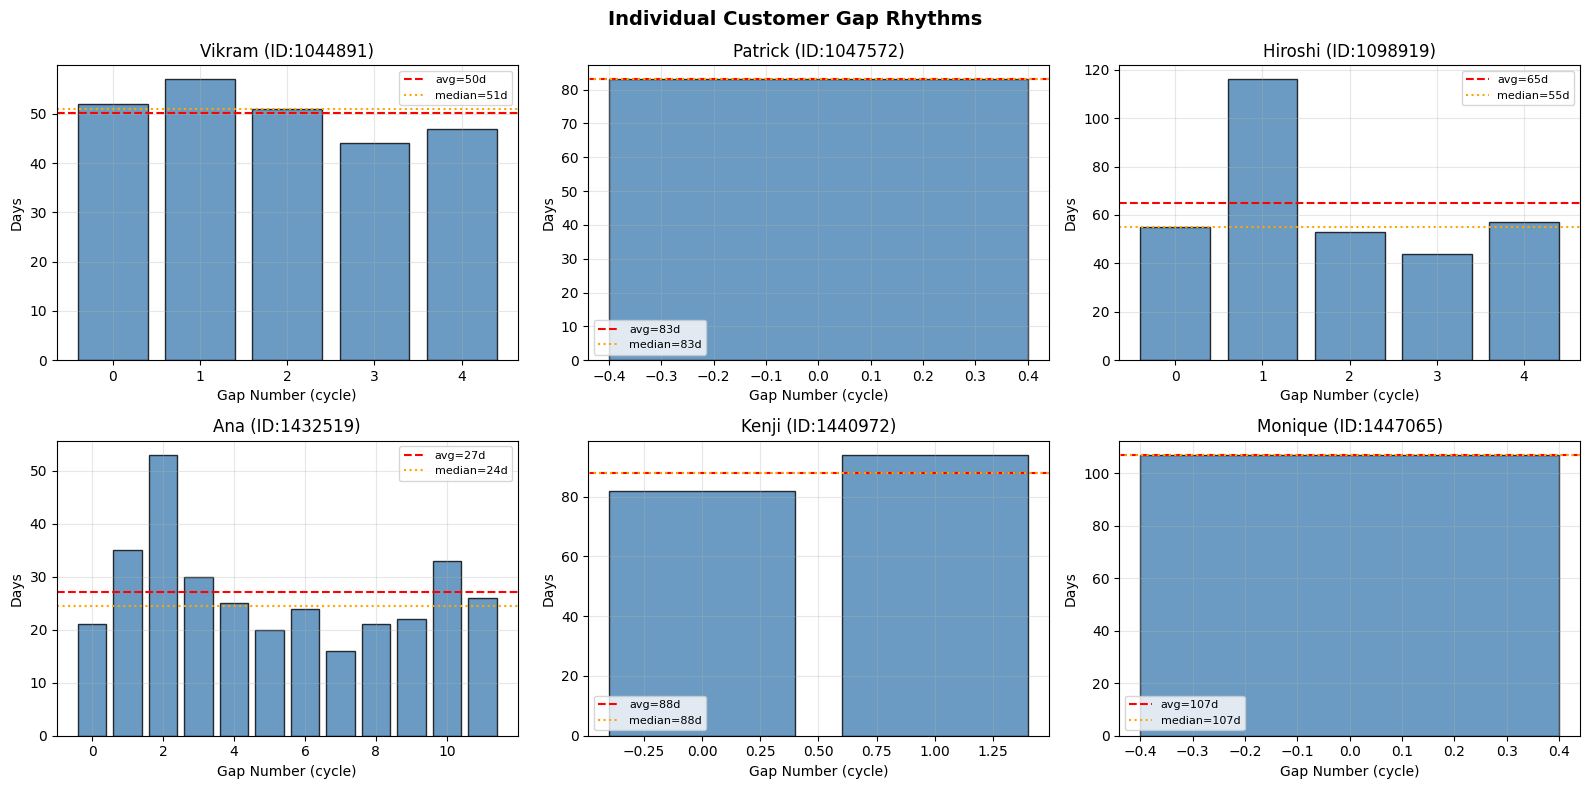

In [15]:
# ===== STEP 6: VISUALIZE INDIVIDUAL CUSTOMER GAP TIMELINES =====
# Pick a sample — see their actual gap rhythm over time

sample_ids = gap_data['customer_id'].unique()[:6]   # first 6 repeat customers

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, cust_id in enumerate(sample_ids):
    cust = gap_data[gap_data['customer_id'] == cust_id].copy()
    name = cust['first_name'].iloc[0]
    
    axes[i].bar(range(len(cust)), cust['day_gap'], 
                color='steelblue', edgecolor='black', alpha=0.8)
    axes[i].axhline(cust['day_gap'].mean(), color='red', 
                    linestyle='--', label=f"avg={cust['day_gap'].mean():.0f}d")
    axes[i].axhline(cust['day_gap'].median(), color='orange', 
                    linestyle=':', label=f"median={cust['day_gap'].median():.0f}d")
    axes[i].set_title(f'{name} (ID:{cust_id})')
    axes[i].set_xlabel('Gap Number (cycle)')
    axes[i].set_ylabel('Days')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Individual Customer Gap Rhythms', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

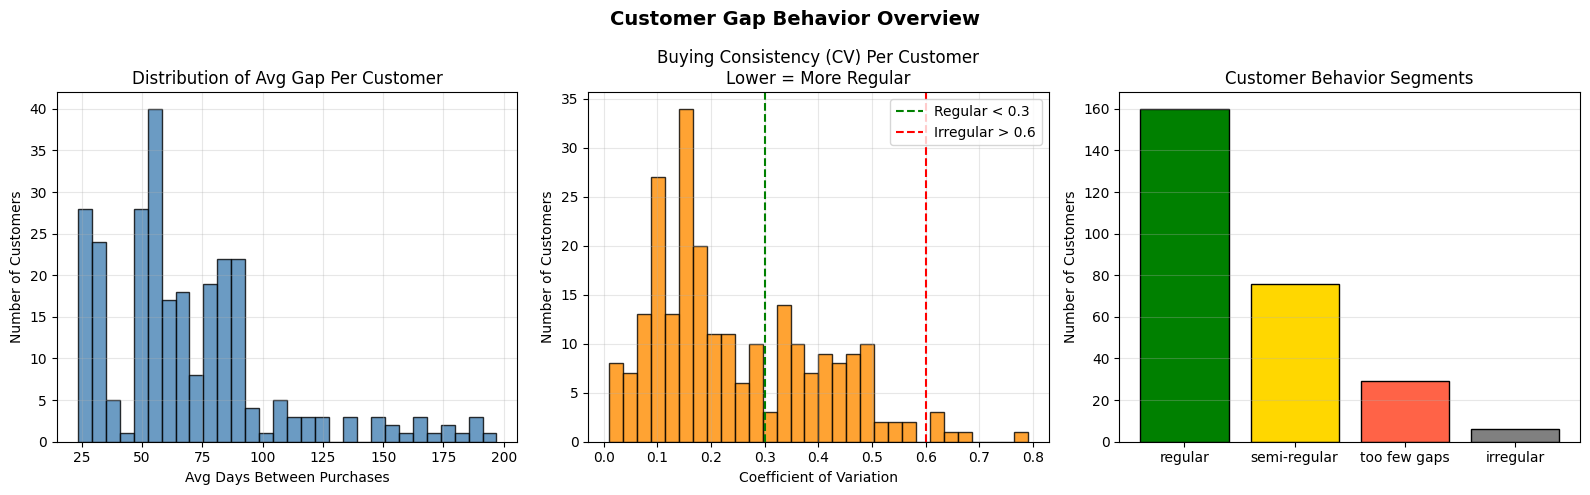

In [16]:
# ===== STEP 7: OVERALL GAP BEHAVIOR SUMMARY =====
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Chart 1 — Distribution of avg gap across all customers
axes[0].hist(gap_profile['avg_gap'], bins=30, 
             color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Distribution of Avg Gap Per Customer')
axes[0].set_xlabel('Avg Days Between Purchases')
axes[0].set_ylabel('Number of Customers')
axes[0].grid(True, alpha=0.3)

# Chart 2 — Consistency (CV) distribution
axes[1].hist(gap_profile['CV'].dropna(), bins=30, 
             color='darkorange', edgecolor='black', alpha=0.8)
axes[1].axvline(0.3, color='green', linestyle='--', label='Regular < 0.3')
axes[1].axvline(0.6, color='red',   linestyle='--', label='Irregular > 0.6')
axes[1].set_title('Buying Consistency (CV) Per Customer\nLower = More Regular')
axes[1].set_xlabel('Coefficient of Variation')
axes[1].set_ylabel('Number of Customers')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Chart 3 — Behavior segments
behavior_counts = gap_profile['behavior'].value_counts()
axes[2].bar(behavior_counts.index, behavior_counts.values,
            color=['green','gold','tomato','gray'], edgecolor='black')
axes[2].set_title('Customer Behavior Segments')
axes[2].set_ylabel('Number of Customers')
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Customer Gap Behavior Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
# ===== STEP 8: PRINT CLEAN READABLE REPORT =====
print("=" * 55)
print("       CUSTOMER PURCHASE BEHAVIOR REPORT")
print("=" * 55)

for _, row in gap_profile.sort_values('avg_gap').iterrows():
    cust_name = data[data['customer_id'] == row['customer_id']]['first_name'].iloc[0]
    print(f"\n👤 {cust_name:<15} (ID: {int(row['customer_id'])})")
    print(f"   Purchases     : {int(row['num_gaps']) + 1}")
    print(f"   Avg gap       : {row['avg_gap']} days")
    print(f"   Median gap    : {row['median_gap']} days")
    print(f"   Range         : {row['min_gap']} – {row['max_gap']} days")
    print(f"   Consistency   : {row['CV']}  → {row['behavior']}")
    print(f"   Pattern       : {row['purchase_pattern']}")

       CUSTOMER PURCHASE BEHAVIOR REPORT

👤 Ana             (ID: 4052834)
   Purchases     : 10
   Avg gap       : 23.4 days
   Median gap    : 23.0 days
   Range         : 17.0 – 30.0 days
   Consistency   : 0.19  → regular
   Pattern       : steady

👤 Stephen         (ID: 9517169)
   Purchases     : 14
   Avg gap       : 23.9 days
   Median gap    : 22.0 days
   Range         : 16.0 – 37.0 days
   Consistency   : 0.26  → regular
   Pattern       : steady

👤 Gunnar          (ID: 7224540)
   Purchases     : 13
   Avg gap       : 24.1 days
   Median gap    : 24.5 days
   Range         : 15.0 – 33.0 days
   Consistency   : 0.24  → regular
   Pattern       : steady

👤 Jason           (ID: 4240708)
   Purchases     : 14
   Avg gap       : 24.5 days
   Median gap    : 24.0 days
   Range         : 15.0 – 33.0 days
   Consistency   : 0.21  → regular
   Pattern       : steady

👤 Jerome          (ID: 9796605)
   Purchases     : 10
   Avg gap       : 24.9 days
   Median gap    : 28.0 days
   Ran

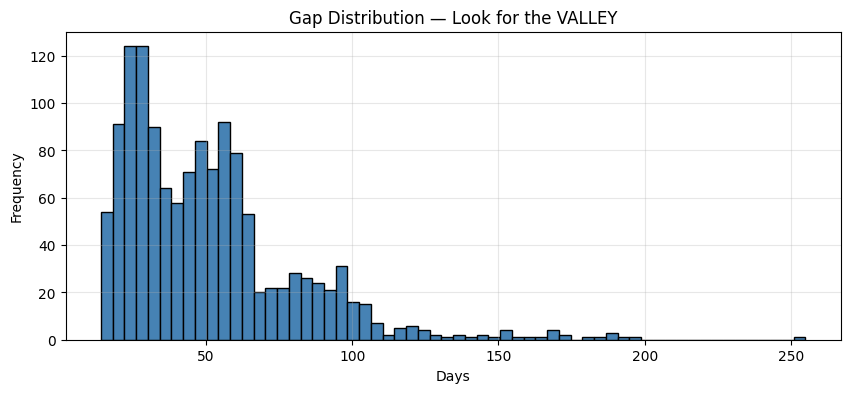

In [18]:
# ===== AFTER calculating day_gap =====

# Step 1: Look at the gap histogram FIRST
gaps = data['day_gap'].dropna()

plt.figure(figsize=(10, 4))
plt.hist(gaps, bins=60, color='steelblue', edgecolor='black')
plt.title('Gap Distribution — Look for the VALLEY')
plt.xlabel('Days')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

# The valley in this histogram is your natural threshold
# Example: gaps cluster at 0-30 AND at 80-130 → valley is around 50

In [19]:
# Step 3: Split every customer's gaps into TWO groups using threshold

def analyze_two_clocks(group):
    gaps = group['day_gap'].dropna()
    if len(gaps) == 0:
        return pd.Series({
            'inner_clock_avg' : np.nan,   # within-burst rhythm
            'outer_clock_avg' : np.nan,   # hibernation rhythm
            'inner_gap_count' : 0,
            'outer_gap_count' : 0,
            'pattern'         : 'no gaps'
        })
    
    inner = gaps[gaps <= threshold]   # small gaps = active buying
    outer = gaps[gaps >  threshold]   # large gaps = hibernation

    # Decide pattern
    if len(inner) > 0 and len(outer) > 0:
        pattern = 'burst + hibernation'   # TWO clocks exist
    elif len(inner) > 0:
        pattern = 'steady buyer'          # only small gaps, never disappears
    else:
        pattern = 'slow buyer'            # all gaps are large

    return pd.Series({
        'inner_clock_avg' : inner.mean().round(1) if len(inner) > 0 else np.nan,
        'outer_clock_avg' : outer.mean().round(1) if len(outer) > 0 else np.nan,
        'inner_gap_count' : len(inner),
        'outer_gap_count' : len(outer),
        'pattern'         : pattern
    })

two_clock_profile = (data[data['day_gap'].notna()]
                     .groupby('customer_id')
                     .apply(analyze_two_clocks)
                     .reset_index())

print(two_clock_profile)
print("\n=== Pattern Counts ===")
print(two_clock_profile['pattern'].value_counts())

     customer_id  inner_clock_avg  outer_clock_avg  inner_gap_count  \
0        1044891             50.2              NaN                5   
1        1047572              NaN             83.0                0   
2        1098919             52.2            116.0                4   
3        1432519             27.2              NaN               12   
4        1440972              NaN             88.0                0   
..           ...              ...              ...              ...   
266      9935249             77.0             97.0                1   
267      9961299              NaN            106.0                0   
268      9988193              NaN            174.0                0   
269      9993490             46.4             81.0                5   
270      9996207             29.1              NaN                9   

     outer_gap_count              pattern  
0                  0         steady buyer  
1                  1           slow buyer  
2              

/tmp/ipykernel_31773/3420277610.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(analyze_two_clocks)


In [20]:
# Step 3: Split every customer's gaps into TWO groups using threshold

def analyze_two_clocks(group):
    gaps = group['day_gap'].dropna()
    if len(gaps) == 0:
        return pd.Series({
            'inner_clock_avg' : np.nan,   # within-burst rhythm
            'outer_clock_avg' : np.nan,   # hibernation rhythm
            'inner_gap_count' : 0,
            'outer_gap_count' : 0,
            'pattern'         : 'no gaps'
        })
    
    inner = gaps[gaps <= threshold]   # small gaps = active buying
    outer = gaps[gaps >  threshold]   # large gaps = hibernation

    # Decide pattern
    if len(inner) > 0 and len(outer) > 0:
        pattern = 'burst + hibernation'   # TWO clocks exist
    elif len(inner) > 0:
        pattern = 'steady buyer'          # only small gaps, never disappears
    else:
        pattern = 'slow buyer'            # all gaps are large

    return pd.Series({
        'inner_clock_avg' : inner.mean().round(1) if len(inner) > 0 else np.nan,
        'outer_clock_avg' : outer.mean().round(1) if len(outer) > 0 else np.nan,
        'inner_gap_count' : len(inner),
        'outer_gap_count' : len(outer),
        'pattern'         : pattern
    })

two_clock_profile = (data[data['day_gap'].notna()]
                     .groupby('customer_id')
                     .apply(analyze_two_clocks)
                     .reset_index())

print(two_clock_profile)
print("\n=== Pattern Counts ===")
print(two_clock_profile['pattern'].value_counts())

     customer_id  inner_clock_avg  outer_clock_avg  inner_gap_count  \
0        1044891             50.2              NaN                5   
1        1047572              NaN             83.0                0   
2        1098919             52.2            116.0                4   
3        1432519             27.2              NaN               12   
4        1440972              NaN             88.0                0   
..           ...              ...              ...              ...   
266      9935249             77.0             97.0                1   
267      9961299              NaN            106.0                0   
268      9988193              NaN            174.0                0   
269      9993490             46.4             81.0                5   
270      9996207             29.1              NaN                9   

     outer_gap_count              pattern  
0                  0         steady buyer  
1                  1           slow buyer  
2              

/tmp/ipykernel_31773/3420277610.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(analyze_two_clocks)


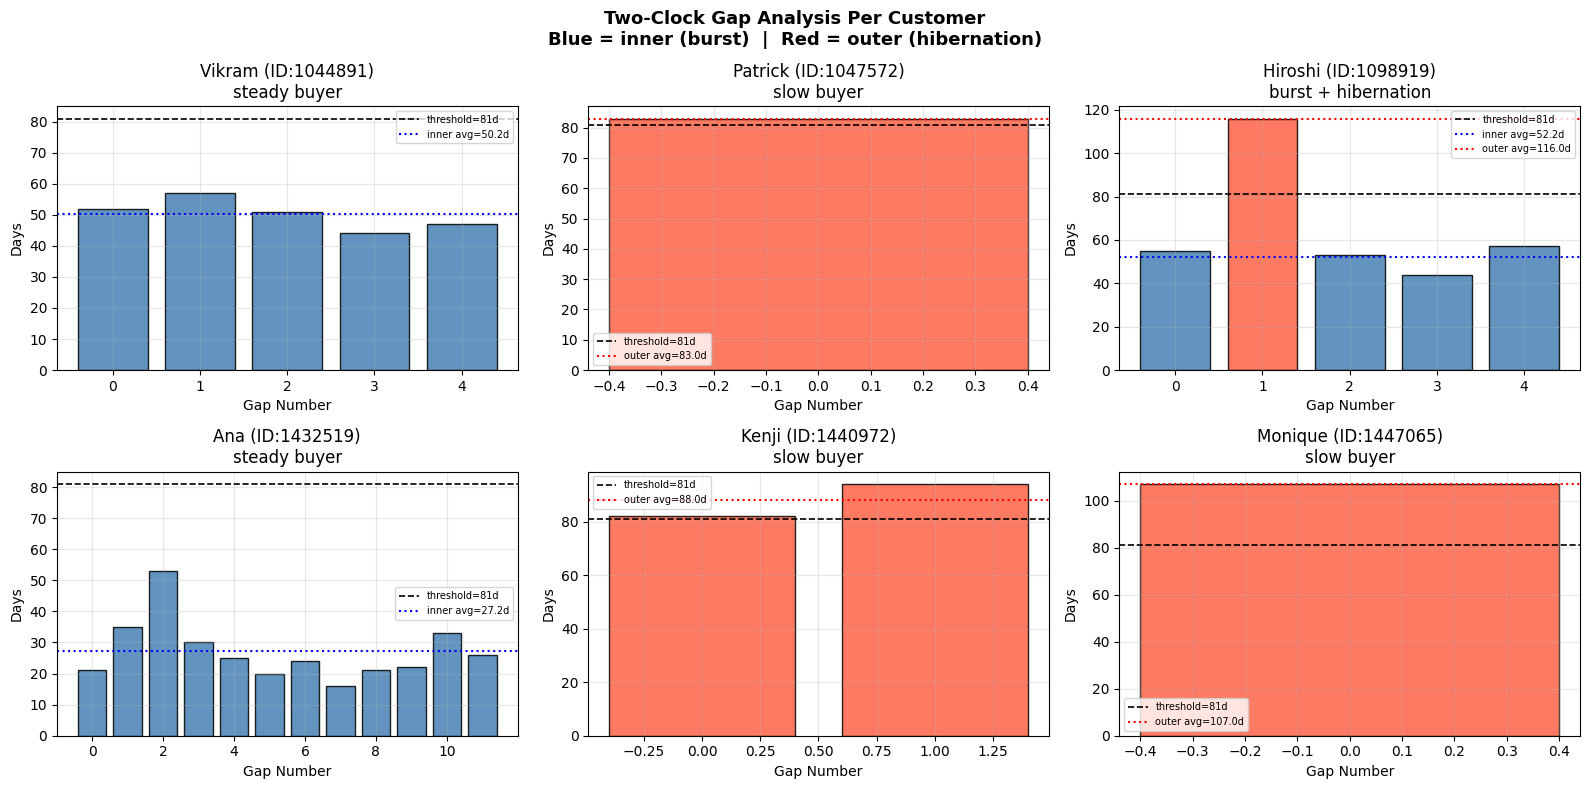

In [21]:
# Step 4: Visualize — gaps clearly split by threshold per customer

sample_ids = data[data['day_gap'].notna()]['customer_id'].unique()[:6]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, cust_id in enumerate(sample_ids):
    cust_gaps = data[(data['customer_id'] == cust_id) & 
                     (data['day_gap'].notna())]['day_gap']
    name = data[data['customer_id'] == cust_id]['first_name'].iloc[0]
    
    # Color bars by which clock they belong to
    colors = ['steelblue' if g <= threshold else 'tomato' for g in cust_gaps]
    
    axes[i].bar(range(len(cust_gaps)), cust_gaps, color=colors, edgecolor='black', alpha=0.85)
    axes[i].axhline(threshold, color='black', linestyle='--', linewidth=1.2,
                    label=f'threshold={threshold:.0f}d')
    
    # Show the two averages separately
    profile_row = two_clock_profile[two_clock_profile['customer_id'] == cust_id]
    if not profile_row.empty:
        inner = profile_row['inner_clock_avg'].values[0]
        outer = profile_row['outer_clock_avg'].values[0]
        if pd.notna(inner):
            axes[i].axhline(inner, color='blue', linestyle=':', 
                            label=f'inner avg={inner}d')
        if pd.notna(outer):
            axes[i].axhline(outer, color='red', linestyle=':', 
                            label=f'outer avg={outer}d')
    
    axes[i].set_title(f'{name} (ID:{cust_id})\n'
                      f'{profile_row["pattern"].values[0] if not profile_row.empty else ""}')
    axes[i].set_xlabel('Gap Number')
    axes[i].set_ylabel('Days')
    axes[i].legend(fontsize=7)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Two-Clock Gap Analysis Per Customer\n'
             'Blue = inner (burst)  |  Red = outer (hibernation)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()